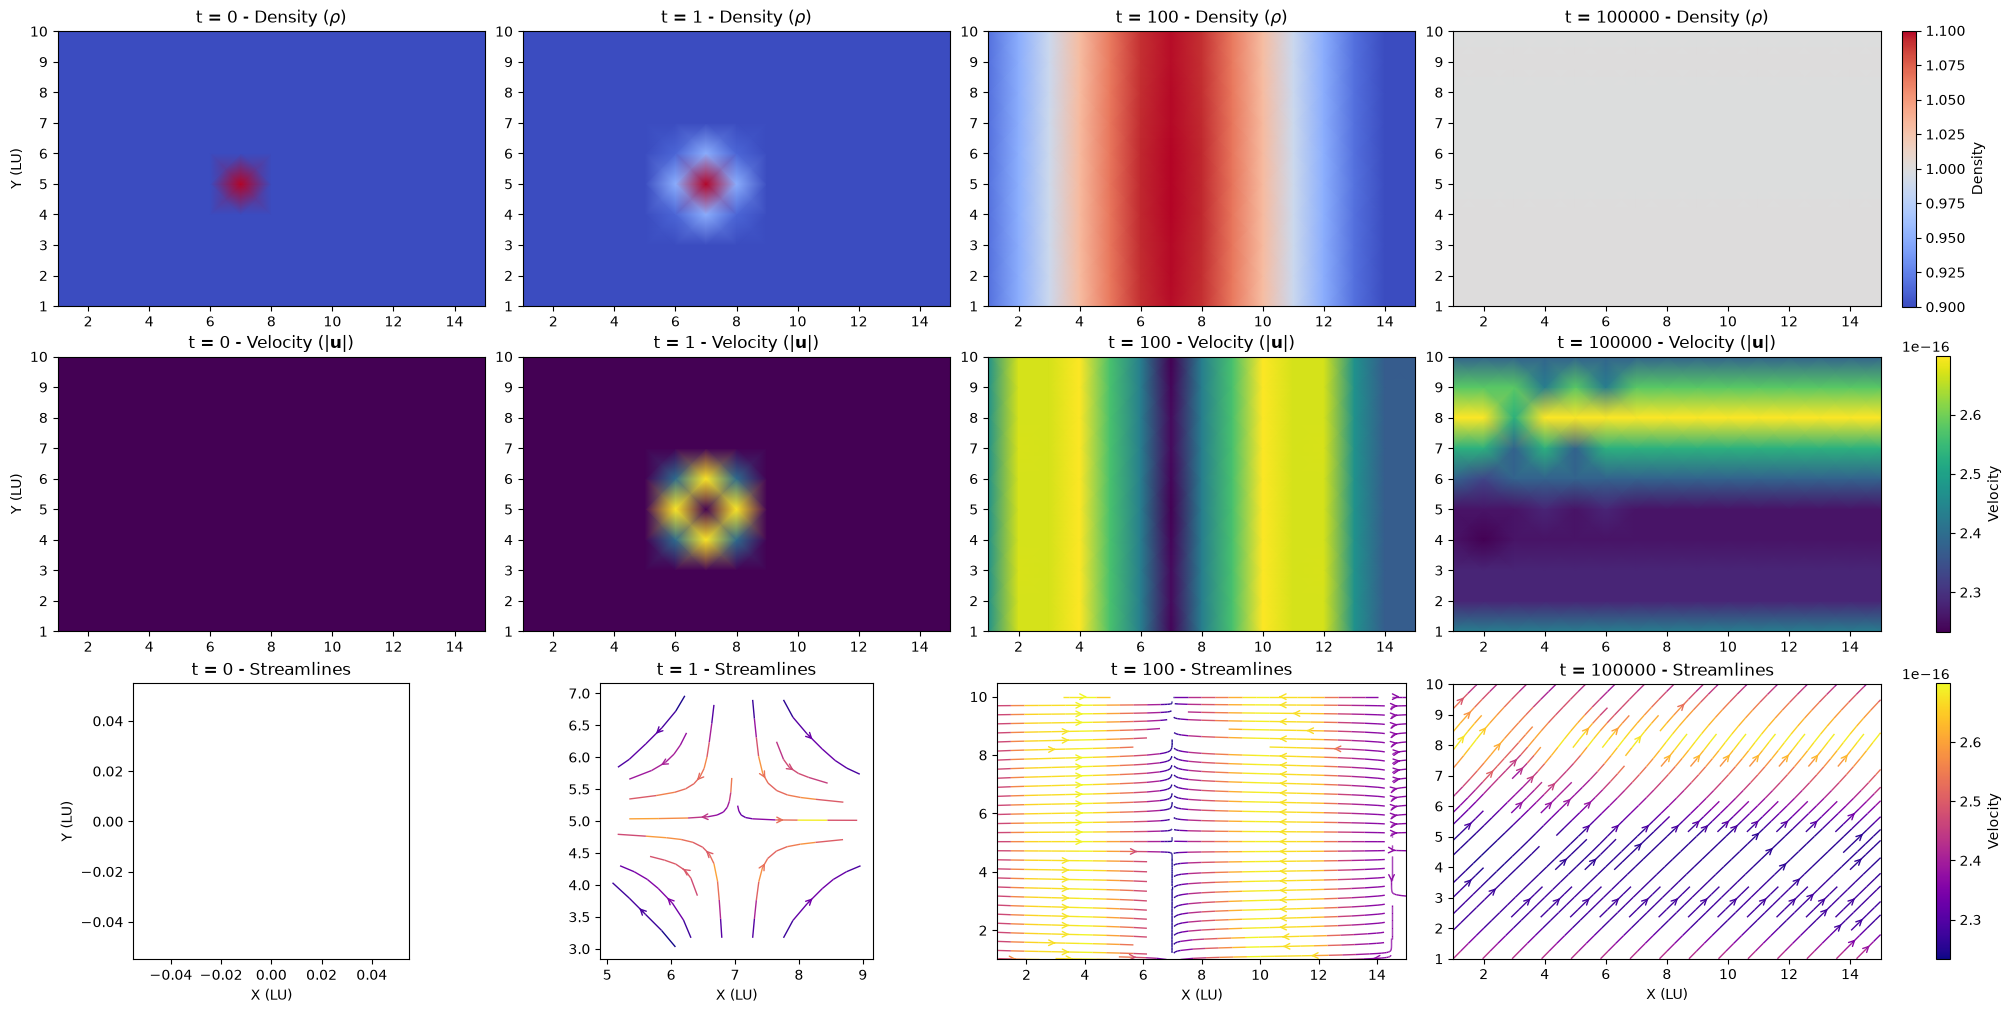

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def load_lbm_data_from_txt(filename):
    """
    Loads LBM data from a text file formatted as: x, y, rho, ux, uy
    """
    try:
        data = np.loadtxt(filename, delimiter=',')
    except Exception as e:
        print(f"Error reading {filename}. Details: {e}")
        return None

    x_1d, y_1d = data[:, 0], data[:, 1]
    rho_1d = data[:, 2]
    ux_1d, uy_1d = data[:, 3], data[:, 4]

    x_unique, y_unique = np.unique(x_1d), np.unique(y_1d)
    nx, ny = len(x_unique), len(y_unique)
    dx = x_unique[1] - x_unique[0] if nx > 1 else 1.0
    dy = y_unique[1] - y_unique[0] if ny > 1 else 1.0

    X, Y = np.meshgrid(x_unique, y_unique)
    U, V, Rho = np.zeros((ny, nx)), np.zeros((ny, nx)), np.zeros((ny, nx))

    col_indices = np.round((x_1d - x_unique[0]) / dx).astype(int)
    row_indices = np.round((y_1d - y_unique[0]) / dy).astype(int)

    U[row_indices, col_indices] = ux_1d
    V[row_indices, col_indices] = uy_1d
    Rho[row_indices, col_indices] = rho_1d

    vel_mag = np.sqrt(U**2 + V**2)

    return X, Y, U, V, Rho, vel_mag

def visualize_multiple_timesteps(filenames, step_labels=None):
    """
    Creates a side-by-side comparison grid for multiple LBM time steps.
    Rows: Density, Velocity Magnitude, Streamlines.
    Columns: Time steps.
    """
    num_steps = len(filenames)
    if num_steps == 0:
        print("No files provided.")
        return

    # If no labels are provided, just use "Step 1, Step 2, etc."
    if step_labels is None:
        step_labels = [f"Time Step {i+1}" for i in range(num_steps)]

    # Create a grid: 3 rows (variables), N columns (time steps)
    # Adjust the figsize dynamically based on how many files are loaded
    fig, axes = plt.subplots(3, num_steps, figsize=(5 * num_steps, 10), constrained_layout=True)
    
    # If there is only one file, axes is 1D. Let's make it 2D for consistent indexing
    if num_steps == 1:
        axes = np.expand_dims(axes, axis=1)

    for col, (filename, label) in enumerate(zip(filenames, step_labels)):
        result = load_lbm_data_from_txt(filename)
        if result is None:
            continue
        
        X, Y, u, v, Rho, vel_mag = result
        x_1d, y_1d = X[0, :], Y[:, 0]

        # Row 0: Density
        ax_rho = axes[0, col]
        mesh_rho = ax_rho.pcolormesh(X, Y, Rho, shading='gouraud', cmap='coolwarm')
        ax_rho.set_title(rf"{label} - Density ($\rho$)", fontsize=12)
        ax_rho.set_aspect('equal')
        # Only add Y-label on the far left column to keep the grid clean
        if col == 0: ax_rho.set_ylabel("Y (LU)")
        # Put the colorbar only on the far right column
        if col == num_steps - 1: fig.colorbar(mesh_rho, ax=ax_rho, label="Density")

        # Row 1: Velocity Magnitude
        ax_vel = axes[1, col]
        mesh_vel = ax_vel.pcolormesh(X, Y, vel_mag, shading='gouraud', cmap='viridis')
        ax_vel.set_title(rf"{label} - Velocity ($|\mathbf{{u}}|$)", fontsize=12)
        ax_vel.set_aspect('equal')
        if col == 0: ax_vel.set_ylabel("Y (LU)")
        if col == num_steps - 1: fig.colorbar(mesh_vel, ax=ax_vel, label="Velocity")

        # Row 2: Streamlines
        ax_strm = axes[2, col]
        strm = ax_strm.streamplot(x_1d, y_1d, u, v, color=vel_mag, cmap='plasma', 
                                  linewidth=1, density=1.0, arrowstyle='->', arrowsize=1)
        ax_strm.set_title(f"{label} - Streamlines", fontsize=12)
        ax_strm.set_xlabel("X (LU)")
        ax_strm.set_aspect('equal')
        if col == 0: ax_strm.set_ylabel("Y (LU)")
        if col == num_steps - 1: fig.colorbar(strm.lines, ax=ax_strm, label="Velocity")

    plt.show()

if __name__ == "__main__":
    # Example usage: Add your actual filenames here in chronological order
    data_files = [
        "output-0.txt", 
        "output-1.txt", 
        "output-100.txt",
        "output-100000.txt",
    ]
    
    # Optional: Custom labels for the tops of the columns
    labels = ["t = 0", "t = 1", "t = 100", "t = 100000"]
    
    visualize_multiple_timesteps(data_files, step_labels=labels)